# Задание 1. Визуализация данных

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

data_dir = Path('task1') if Path('task1').is_dir() else Path('.')
ships = pd.read_csv(data_dir / 'Cleaned_ships_data.csv')
iris = pd.read_csv(data_dir / 'IRIS.csv')

## 1. Средний максимальный вес груза и длина корабля

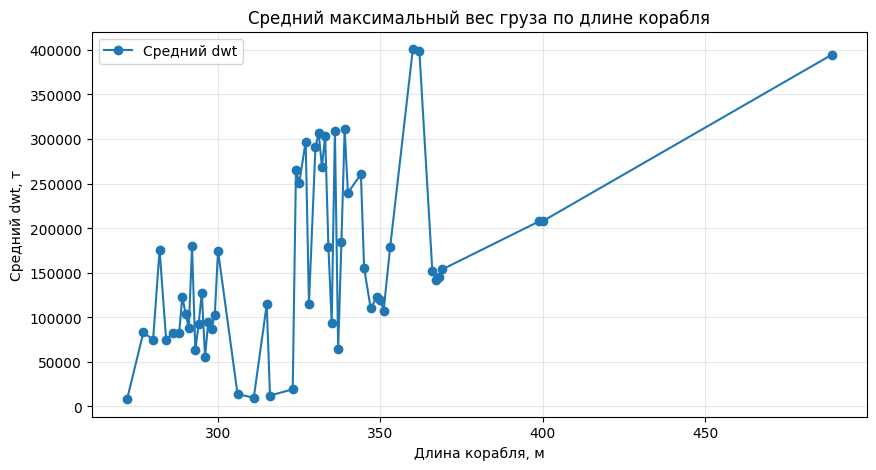

In [2]:
mean_dwt = ships.groupby('length', as_index=False)['dwt'].mean()
mean_dwt = mean_dwt.sort_values('length')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mean_dwt['length'], mean_dwt['dwt'], marker='o', label='Средний dwt')
ax.set(title='Средний максимальный вес груза по длине корабля',
       xlabel='Длина корабля, м', ylabel='Средний dwt, т')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 2. Количество кораблей по типам

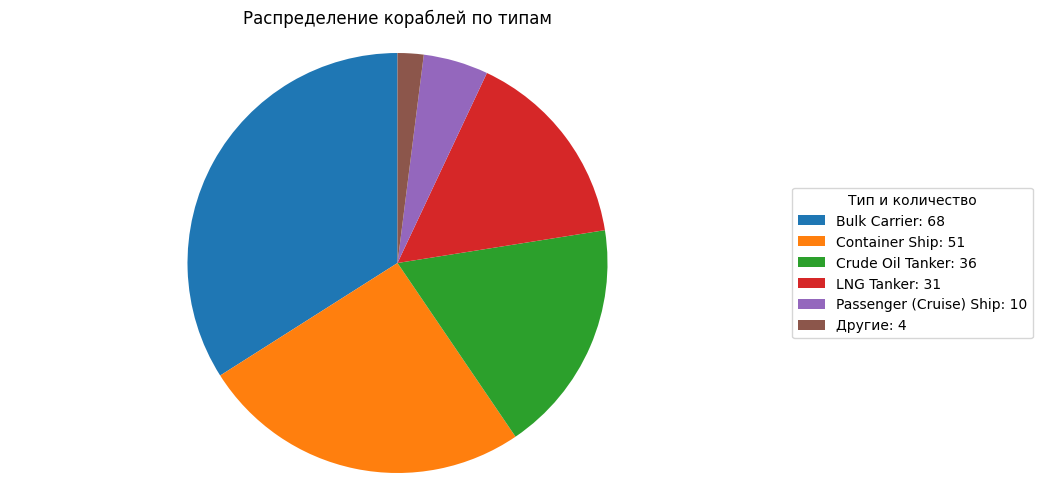

In [3]:
ship_counts = ships['ship_name'].value_counts()
main_types = ship_counts[ship_counts >= 5].copy()
other_count = ship_counts[ship_counts < 5].sum()
if other_count > 0:
    main_types.loc['Другие'] = other_count

fig, ax = plt.subplots(figsize=(10, 6))
wedges, _ = ax.pie(main_types, startangle=90)
labels = [f'{name}: {count}' for name, count in main_types.items()]
ax.legend(wedges, labels, title='Тип и количество',
          loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Распределение кораблей по типам')
ax.axis('equal')
plt.show()

## 3. Количество кораблей по годам постройки

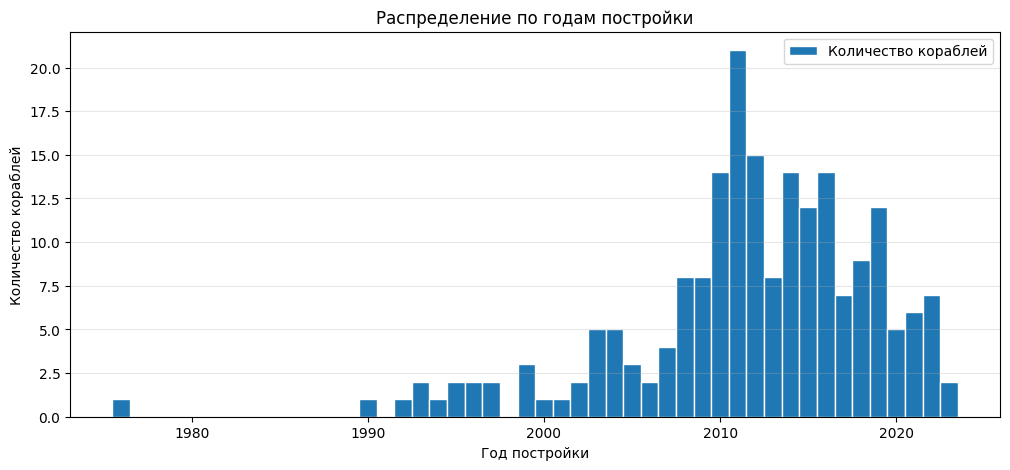

In [4]:
year_bins = np.arange(ships['built_year'].min() - 0.5,
                      ships['built_year'].max() + 1.5)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(ships['built_year'], bins=year_bins, edgecolor='white',
        label='Количество кораблей')
ax.set(title='Распределение по годам постройки',
       xlabel='Год постройки', ylabel='Количество кораблей')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

## 4. Год постройки и максимальный вес груза

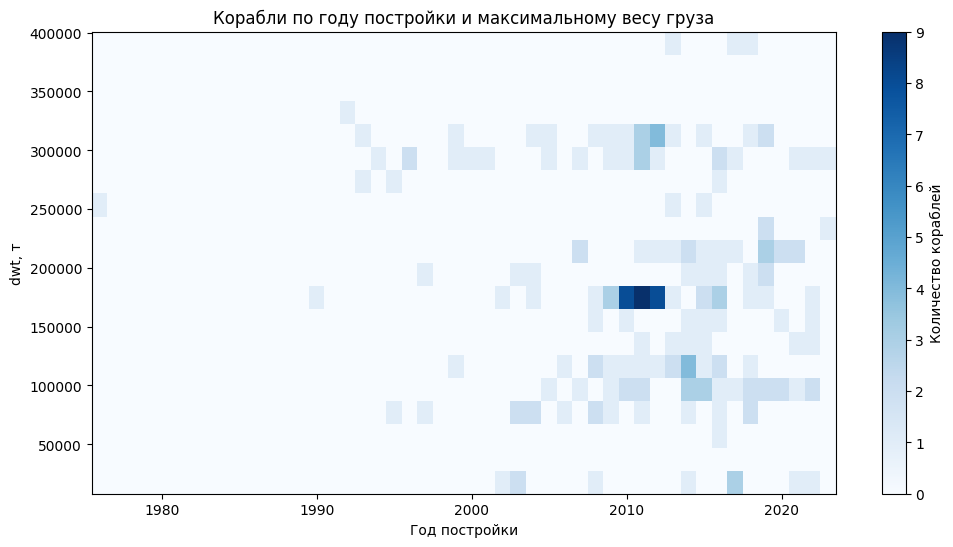

In [5]:
dwt_bins = np.linspace(ships['dwt'].min(), ships['dwt'].max(), 21)

fig, ax = plt.subplots(figsize=(12, 6))
hist = ax.hist2d(ships['built_year'], ships['dwt'],
                 bins=[year_bins, dwt_bins], cmap='Blues')
fig.colorbar(hist[3], ax=ax, label='Количество кораблей')
ax.set(title='Корабли по году постройки и максимальному весу груза',
       xlabel='Год постройки', ylabel='dwt, т')
plt.show()

## 5. Парная диаграмма ирисов

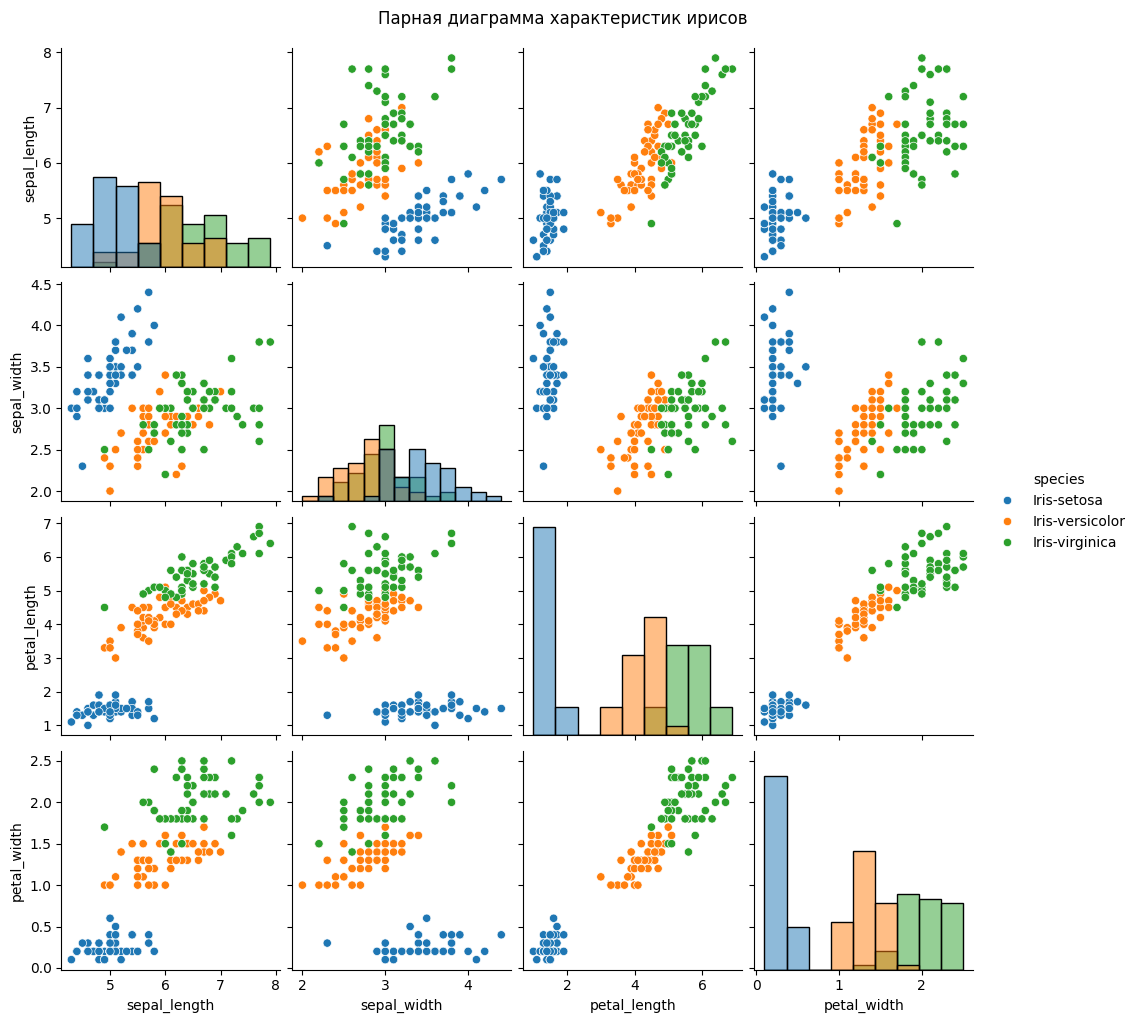

In [3]:
iris_features = ['sepal_length', 'sepal_width',
                 'petal_length', 'petal_width']
grid = sns.pairplot(iris, vars=iris_features, hue='species',
                    diag_kind='hist')
grid.figure.suptitle('Парная диаграмма характеристик ирисов', y=1.02)
plt.show()

## 6. Распределение характеристик ирисов по видам

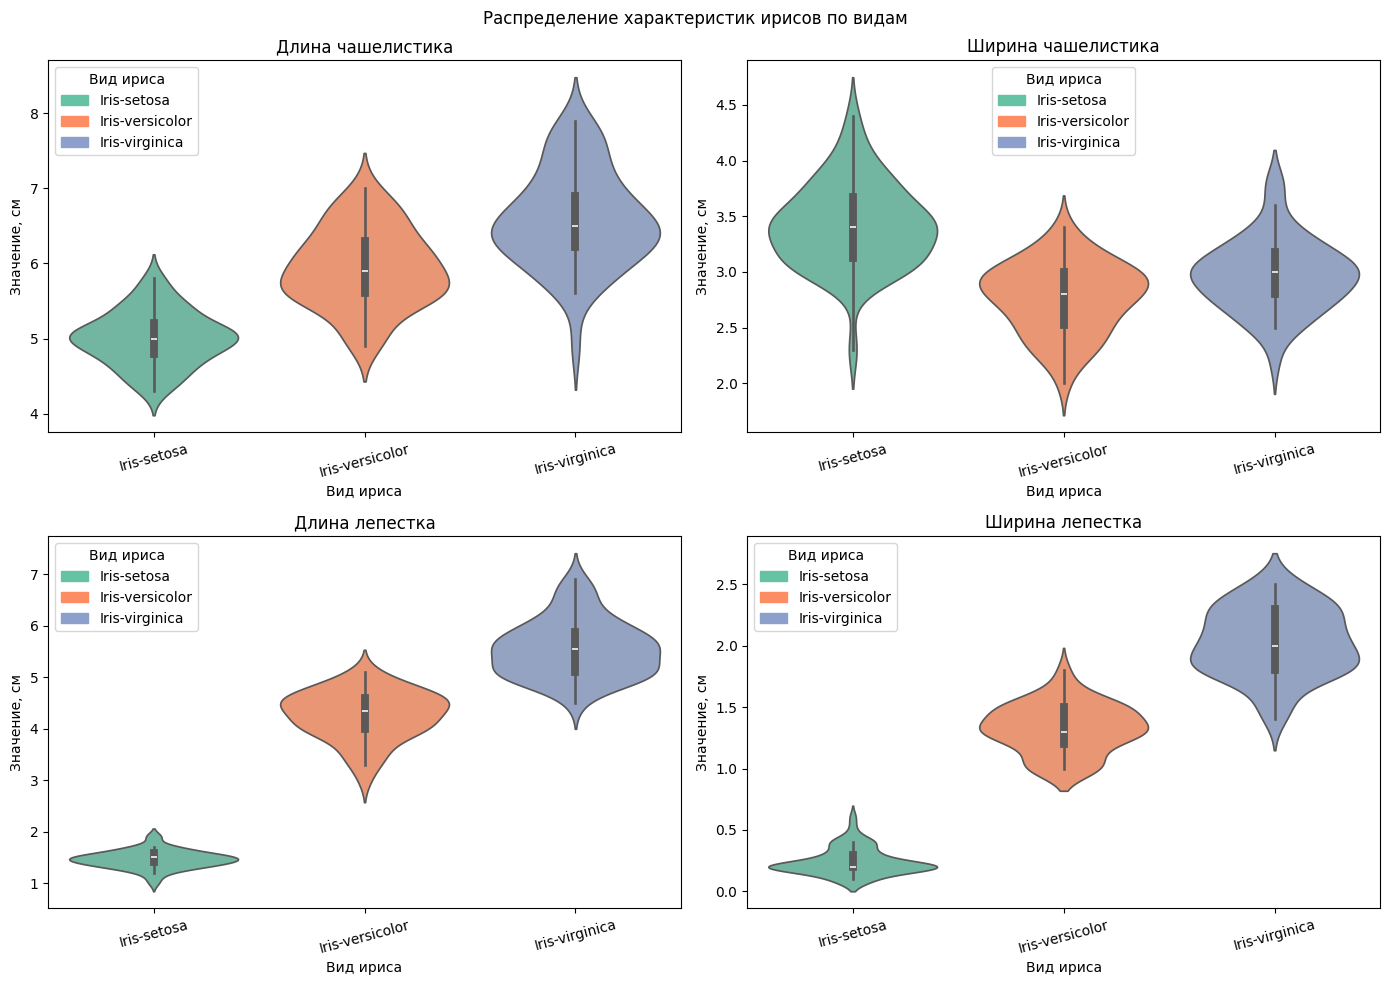

In [7]:
species = iris['species'].unique()
colors = dict(zip(species, sns.color_palette('Set2', len(species))))
titles = ['Длина чашелистика', 'Ширина чашелистика',
          'Длина лепестка', 'Ширина лепестка']
legend_items = [Patch(color=colors[name], label=name) for name in species]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature, title in zip(axes.flat, iris_features, titles):
    sns.violinplot(data=iris, x='species', y=feature, hue='species',
                   palette=colors, dodge=False, ax=ax)
    ax.set(title=title, xlabel='Вид ириса', ylabel='Значение, см')
    ax.legend(handles=legend_items, title='Вид ириса')
    ax.tick_params(axis='x', labelrotation=15)

fig.suptitle('Распределение характеристик ирисов по видам')
fig.tight_layout()
plt.show()